In [1]:
!cd ../../.. && maturin develop --uv

📦 Including license file "LICENSE"
🔗 Found uniffi bindings
📡 Using build options features from pyproject.toml
   Compiling orcapod v0.1.0 (/workspaces/orcapod)
   --> src/uniffi/orchestrator/agent.rs:194:20
    |
194 |             async |agent, inner_namespace_lookup, metadata, pipeline_jo...
    |                    ^^^^^ help: if this is intentional, prefix it with an underscore: `_agent`
    |
    = note: `#[warn(unused_variables)]` on by default

   --> src/uniffi/orchestrator/agent.rs:194:27
    |
194 | ...     async |agent, inner_namespace_lookup, metadata, pipeline_job: P...
    |                       ^^^^^^^^^^^^^^^^^^^^^^ help: if this is intentional, prefix it with an underscore: `_inner_namespace_lookup`

 --> src/core/operator.rs:8:8
  |
7 | pub trait Operator {
  |           -------- method in this trait
8 |     fn next(&mut self, packets: Vec<(String, Packet)>) -> Result<Vec<Pack...
  |        ^^^^
  |
  = note: `#[warn(dead_code)]` on by default

  --> src/core/operator

In [2]:
from pathlib import Path
import asyncio
from orcapod import (
    Pod,
    PodJob,
    Uri,
    PathInfo,
    PathSet,
    Blob,
    BlobKind,
    Pipeline,
    PipelineJob,
    InputSpecUri,
    OutputSpecUri,
    Kernel,
    Agent,
    AgentClient,
    LocalDockerOrchestrator,
    LocalFileStore,
)

In [3]:
namespace_lookup = {"default": "../../.tmp"}
root_dir = "test"
data_dir = f"{root_dir}/data"
store_dir = f"{root_dir}/store"

In [4]:
group = "test"
host = "alpha"

## Setup

In [5]:
input_dir = Path(namespace_lookup["default"]) / data_dir / "input"
input_dir.mkdir(parents=True, exist_ok=True)
for i in range(1, 16):
    (input_dir / f"{i}.txt").write_text(str(i))

In [6]:
add_pod = Pod(
    annotation=None,
    image="alpine:3.14",
    command=[
        "sh",
        "-c",
        """echo
            echo 'Adding two numbers'
            echo $(($(cat /tmp/input/left.txt)+$(cat /tmp/input/right.txt))) > /tmp/output/answer.txt
            echo Finished
        echo""".replace(
            "\n", " && "
        ),
    ],
    input_spec={
        "left": PathInfo(path="/tmp/input/left.txt", match_pattern=".*\.txt"),
        "right": PathInfo(path="/tmp/input/right.txt", match_pattern=".*\.txt"),
    },
    output_dir="/tmp/output",
    output_spec={
        "answer": PathInfo(path="/tmp/output/answer.txt", match_pattern=".*\.txt")
    },
    source_commit_url="https://place.holder",
    recommended_cpus=0.1,
    recommended_memory=10 << 20,
    required_gpu=None,
)

In [7]:
orch = LocalDockerOrchestrator()

In [8]:
store = LocalFileStore(directory=store_dir)

## PodJob Test

In [ ]:
add_pod_job = PodJob(
    annotation=None,
    pod=add_pod,
    input_packet={
        "left": PathSet.UNARY(
            blob=Blob(
                kind=BlobKind.FILE,
                location=Uri(namespace="default", path=f"{data_dir}/input/2.txt"),
                checksum="",
            )
        ),
        "right": PathSet.UNARY(
            blob=Blob(
                kind=BlobKind.FILE,
                location=Uri(namespace="default", path=f"{data_dir}/input/7.txt"),
                checksum="",
            )
        ),
    },
    output_dir=Uri(namespace="default", path=f"{data_dir}/output"),
    cpu_limit=0.1,
    memory_limit=10 << 20,
    env_vars=None,
    namespace_lookup=namespace_lookup,
)

In [ ]:
pod_run = orch.start_blocking(namespace_lookup=namespace_lookup, pod_job=add_pod_job)
pod_result = orch.get_result_blocking(pod_run=pod_run)

In [ ]:
orch.delete_blocking(pod_run=pod_run)

## PipelineJob Test

In [9]:
from IPython.display import SVG

In [10]:
map_left = {"answer": "left"}
map_right = {"answer": "right"}

In [11]:
pipeline = Pipeline(
    graph_dot="""
    digraph {
        add_a -> map_left_a -> cartesian_a -> add_e
        add_b -> map_right_a -> cartesian_a

        add_c -> map_left_b -> cartesian_b -> add_f
        add_d -> map_right_b -> cartesian_b

        add_e -> map_left_c -> cartesian_c -> add_g
        add_f -> map_right_c -> cartesian_c
    }
    """,
    metadata={
        **{
            f"add_{k}": Kernel.POD(ref=add_pod)
            for k in ["a", "b", "c", "d", "e", "f", "g"]
        },
        **{f"map_left_{k}": Kernel.MAP_OPERATOR(map=map_left) for k in ["a", "b", "c"]},
        **{
            f"map_right_{k}": Kernel.MAP_OPERATOR(map=map_right)
            for k in ["a", "b", "c"]
        },
        **{f"cartesian_{k}": Kernel.JOIN_OPERATOR() for k in ["a", "b", "c"]},
    },
    input_spec={
        **{
            f"left_add_{k}": [InputSpecUri(node_id=f"add_{k}", key="left")]
            for k in ["a", "b", "c", "d"]
        },
        **{
            f"right_add_{k}": [InputSpecUri(node_id=f"add_{k}", key="right")]
            for k in ["a", "b", "c", "d"]
        },
    },
    output_spec={"answer": OutputSpecUri(node_id="add_g", key="answer")},
)

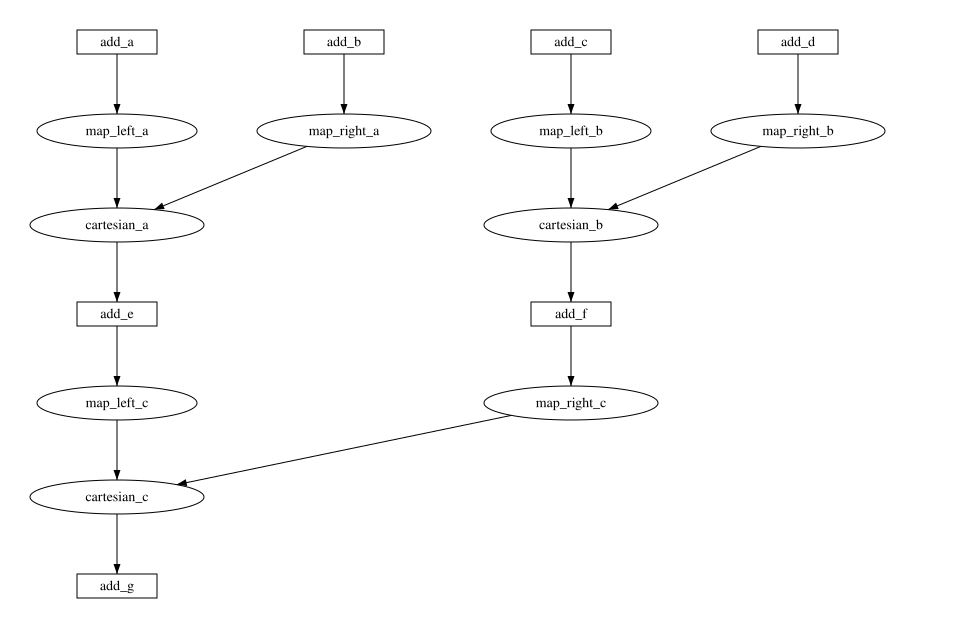

In [12]:
# pipeline.metadata()
# pipeline.metadata()["add_a"].ref.command()
# print(pipeline.make_dot())
SVG(data=pipeline.make_svg())

In [13]:
pipeline_job = PipelineJob(
    pipeline=pipeline,
    input_packet={
        "left_add_a": [
            PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(namespace="default", path=f"{data_dir}/input/{i}.txt"),
                    checksum="",
                )
            )
            for i in range(1, 4)
        ],
        "right_add_a": [
            PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(namespace="default", path=f"{data_dir}/input/{i}.txt"),
                    checksum="",
                )
            )
            for i in range(4, 6)
        ],
        **{
            k: [
                PathSet.UNARY(
                    blob=Blob(
                        kind=BlobKind.FILE,
                        location=Uri(
                            namespace="default", path=f"{data_dir}/input/{i+6}.txt"
                        ),
                        checksum="",
                    )
                )
            ]
            for i, k in enumerate(
                [
                    "left_add_b",
                    "right_add_b",
                    "left_add_c",
                    "right_add_c",
                    "left_add_d",
                    "right_add_d",
                ]
            )
        },
    },
    output_dir=Uri(namespace="default", path=f"{data_dir}/output"),
    namespace_lookup=namespace_lookup,
)

In [14]:
pipeline_job.input_packet()["left_add_a"][0].blob.checksum

'6b86b273ff34fce19d6b804eff5a3f5747ada4eaa22f1d49c01e52ddb7875b4b'

In [15]:
client = AgentClient(group=group, host=host)
agent = Agent(group=group, host=host, orchestrator=orch)

In [ ]:
watcher = asyncio.create_task(client.watch(key_expr="**"))

Watching...


In [ ]:
worker = asyncio.create_task(
    agent.start(namespace_lookup=namespace_lookup, available_store=store)
)

Started `request/pod_job/**` service.
Started `request/pipeline_job/**` service.
group/test/log/host/alpha/timestamp/2025-07-06T15:16:44.314554240+00:00: "Started `request/pod_job/**` service."
Started `success/pod_job/**` service.
group/test/log/host/alpha/timestamp/2025-07-06T15:16:44.315753905+00:00: "Started `request/pipeline_job/**` service."
group/test/log/host/alpha/timestamp/2025-07-06T15:16:44.316870248+00:00: "Started `success/pod_job/**` service."
Started `failure/pod_job/**` service.
group/test/log/host/alpha/timestamp/2025-07-06T15:16:44.318045462+00:00: "Started `failure/pod_job/**` service."


In [ ]:
await client.submit_pipeline_job(pipeline_job=pipeline_job)

group/test/request/pipeline_job/c9ef663816f2f3bff0fcbd7127162d28a79563dabfe8cababc51f1364cf54de9/host/alpha/timestamp/2025-07-06T15:16:47.617558375+00:00: {
  "hash": "c9ef663816f2f3bff0fcbd7127162d28a79563dabfe8cababc51f1364cf54de9",
  "input_packet": {
    "left_add_a": [
      {
        "blob": {
          "checksum": "6b86b273ff34fce19d6b804eff5a3f5747ada4eaa22f1d49c01e52ddb7875b4b",
          "kind": "File",
          "location": {
            "namespace": "default",
            "path": "test/data/input/1.txt"
          }
        }
      },
      {
        "blob": {
          "checksum": "d4735e3a265e16eee03f59718b9b5d03019c07d8b6c51f90da3a666eec13ab35",
          "kind": "File",
          "location": {
            "namespace": "default",
            "path": "test/data/input/2.txt"
          }
        }
      },
      {
        "blob": {
          "checksum": "4e07408562bedb8b60ce05c1decfe3ad16b72230967de01f640b7e4729b49fce",
          "kind": "File",
          "location": {
     

    timestamp: 2025-07-06T15:16:47.617558375Z,
}
pipeline_job: PipelineJob {
    hash: "c9ef663816f2f3bff0fcbd7127162d28a79563dabfe8cababc51f1364cf54de9",
    pipeline: Pipeline {
        graph: Graph {
            Ty: "Directed",
            node_count: 16,
            edge_count: 15,
            edges: (0, 1), (1, 2), (2, 3), (4, 5), (5, 2), (6, 7), (7, 8), (8, 9), (10, 11), (11, 8), (3, 12), (12, 13), (13, 14), (9, 15), (15, 13),
            node weights: {
                0: "add_a",
                1: "map_left_a",
                2: "cartesian_a",
                3: "add_e",
                4: "add_b",
                5: "map_right_a",
                6: "add_c",
                7: "map_left_b",
                8: "cartesian_b",
                9: "add_f",
                10: "add_d",
                11: "map_right_b",
                12: "map_left_c",
                13: "cartesian_c",
                14: "add_g",
                15: "map_right_c",
            },
            edg

## Teardown

In [19]:
import shutil

In [ ]:
shutil.rmtree(Path(namespace_lookup["default"]) / data_dir / "output")

In [20]:
shutil.rmtree(Path(namespace_lookup["default"]) / root_dir)